In [1]:
!pip install easyocr


In [1]:
from __future__ import annotations

import argparse
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import cv2
import easyocr
import pandas as pd


DEFAULT_VIDEO_PATH = "/kaggle/input/datasets/yerinim/basketball/1_.mp4"
DEFAULT_OUTPUT_PATH = "/kaggle/working/score_timeline_full_26min_clock_safe_predict.csv"
DEFAULT_INTERVAL_SEC = 1.0
DEFAULT_CONFIRM_COUNT = 2
DEFAULT_RESYNC_COUNT = 3
MAX_RESYNC_SCORE_JUMP = 12
INITIAL_SCORE_WINDOW_SEC = 5.0
MISSING_CONFIRM_COUNT = 3
CUT_EDIT_MISSING_COUNT = 10
MAX_CLOCK_RESYNC_DROP_SEC = 60
CUT_EDIT_CLOCK_ADJUST_SEC = 5

MIN_OCR_CONFIDENCE = 0.25
MIN_INFO_OCR_CONFIDENCE = 0.10
MIN_NUMBER_HEIGHT = 12
MAX_SCORE_VALUE = 200
UNKNOWN = "UNKNOWN"

KNOWN_TEAM_CODES = {
    "ATL",
    "BKN",
    "BOS",
    "CHA",
    "CHI",
    "CLE",
    "DAL",
    "DEN",
    "DET",
    "GSW",
    "GS",
    "HOU",
    "IND",
    "LAC",
    "LAL",
    "MEM",
    "MIA",
    "MIL",
    "MIN",
    "NOP",
    "NYK",
    "NY",
    "OKC",
    "ORL",
    "PHI",
    "PHX",
    "POR",
    "SAC",
    "SAS",
    "SA",
    "TOR",
    "UTA",
    "WAS",
}

TEAM_OCR_ALIASES = {
    "UTAH": "UTA",
    "UIA": "UTA",
    "UT4": "UTA",
    "DENN": "DEN",
    "OEN": "DEN",
    "NETS": "BKN",
    "METS": "BKN",
    "NCTS": "BKN",
    "BROOKLYN": "BKN",
    "MAGIC": "ORL",
    "ORLANDO": "ORL",
}


@dataclass
class OcrItem:
    raw: str
    conf: float
    x: float
    y: float
    width: float
    height: float
    team: str
    roi: str = ""


@dataclass
class NumberCandidate:
    value: int
    raw: str
    conf: float
    x: float
    y: float
    width: float
    height: float
    roi: str = ""


@dataclass
class ParsedScoreboard:
    team1_score: int
    team2_score: int
    team1_name: str
    team2_name: str
    quarter: str
    game_clock: str
    region_score: float

    @property
    def score(self) -> tuple[int, int]:
        return self.team1_score, self.team2_score


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Extract basketball scoreboard OCR timeline.")
    parser.add_argument("--video", default=DEFAULT_VIDEO_PATH, help="Input mp4 video path")
    parser.add_argument("--output", default=DEFAULT_OUTPUT_PATH, help="Output CSV path")
    parser.add_argument("--team1", default=UNKNOWN, help="Manual left team name, e.g. DEN")
    parser.add_argument("--team2", default=UNKNOWN, help="Manual right team name, e.g. UTA")
    parser.add_argument(
        "--left-score-box",
        default="",
        help="Manual left score crop as x1,y1,x2,y2 ratios, e.g. 0.715,0.79,0.775,0.865",
    )
    parser.add_argument(
        "--right-score-box",
        default="",
        help="Manual right score crop as x1,y1,x2,y2 ratios, e.g. 0.835,0.79,0.895,0.865",
    )
    parser.add_argument("--interval", type=float, default=DEFAULT_INTERVAL_SEC, help="Sampling interval in seconds")
    parser.add_argument(
        "--confirm-count",
        type=int,
        default=DEFAULT_CONFIRM_COUNT,
        help="Number of repeated scores required for initial confirmation",
    )
    parser.add_argument(
        "--resync-count",
        type=int,
        default=DEFAULT_RESYNC_COUNT,
        help="Repeated non-decreasing invalid scores required to resync after missed samples",
    )
    parser.add_argument(
        "--record-mode",
        choices=["every-sample", "score-change"],
        default="score-change",
        help="CSV record mode",
    )
    parser.add_argument("--gpu", action="store_true", help="Use EasyOCR GPU mode")
    parser.add_argument("--debug", action="store_true", help="Print OCR number candidates")
    parser.add_argument(
        "--max-samples",
        type=int,
        default=0,
        help="Debug limit. 0 means full video; positive value limits OCR samples.",
    )
    parser.add_argument("--start-sec", type=float, default=None, help="Start time in seconds. None means from the beginning")
    parser.add_argument("--end-sec", type=float, default=None, help="End time in seconds. None means until the end")
    return parser.parse_args()


def parse_box_arg(value: str) -> tuple[float, float, float, float] | None:
    if not value:
        return None

    parts = [part.strip() for part in value.split(",")]
    if len(parts) != 4:
        raise ValueError(f"Box must have 4 comma-separated values: {value}")

    x1, y1, x2, y2 = (float(part) for part in parts)
    if not (0 <= x1 < x2 <= 1 and 0 <= y1 < y2 <= 1):
        raise ValueError(f"Box ratios must satisfy 0 <= x1 < x2 <= 1 and 0 <= y1 < y2 <= 1: {value}")

    return x1, y1, x2, y2


def bbox_bounds(bbox) -> tuple[float, float, float, float]:
    xs = [float(point[0]) for point in bbox]
    ys = [float(point[1]) for point in bbox]
    return min(xs), min(ys), max(xs), max(ys)


def normalize_quarter_text(text: str) -> str:
    compact = re.sub(r"[^0-9A-Z]", "", text.upper())
    compact = compact.replace("OQ", "0Q").replace("5T", "ST").replace("S1", "ST")

    suffix_only = {
        "ST": "1Q",
        "ND": "2Q",
        "RD": "3Q",
        "TH": "4Q",
    }
    for suffix, quarter in suffix_only.items():
        if compact == suffix or compact.endswith(suffix):
            return quarter

    match = re.fullmatch(r"([1-4])Q", compact)
    if match:
        return f"{match.group(1)}Q"

    if compact in {"OT", "0T"}:
        return "OT"

    ordinal_match = re.fullmatch(r"([1-4])(ST|ND|RD|TH)", compact)
    if ordinal_match:
        return f"{ordinal_match.group(1)}Q"

    return ""


def is_quarter_text(text: str) -> bool:
    return normalize_quarter_text(text) != ""


def normalize_game_clock_text(text: str) -> str:
    cleaned = text.upper().strip()
    cleaned = cleaned.replace("O", "0").replace("I", "1").replace("L", "1")
    cleaned = cleaned.replace("|", ":").replace(";", ":").replace(".", ":")

    match = re.search(r"(\d{1,2})\s*:\s*(\d{2})", cleaned)
    if not match:
        return ""

    minute = int(match.group(1))
    second = int(match.group(2))
    if 0 <= minute <= 15 and 0 <= second <= 59:
        return f"{minute:02d}:{second:02d}"
    return ""


def is_game_clock_text(text: str) -> bool:
    return normalize_game_clock_text(text) != ""


def game_clock_to_seconds(clock: str) -> int | None:
    match = re.fullmatch(r"(\d{1,2}):(\d{2})", str(clock).strip())
    if not match:
        return None

    minute = int(match.group(1))
    second = int(match.group(2))
    if 0 <= minute <= 15 and 0 <= second <= 59:
        return minute * 60 + second
    return None


def seconds_to_game_clock(seconds: int) -> str:
    seconds = max(0, int(seconds))
    return f"{seconds // 60:02d}:{seconds % 60:02d}"


def quarter_to_number(quarter: str) -> int | None:
    text = str(quarter).upper().strip()
    match = re.fullmatch(r"([1-4])Q", text)
    if match:
        return int(match.group(1))
    if text == "OT":
        return 5
    return None


def normalize_stable_quarter(
    stable: dict[str, object],
    raw_quarter: str,
    raw_seconds: int | None,
) -> str:
    """Return a stable quarter value without trusting one-off OCR reads.

    Quarter OCR is noisy. A raw quarter can only move forward in order
    and the next quarter must be repeated while the clock looks like a
    quarter-start clock. Backward moves such as 2Q -> 1Q are ignored.
    """
    current = str(stable.get("quarter") or UNKNOWN)
    raw = raw_quarter or ""

    if not raw:
        return current

    raw_num = quarter_to_number(raw)
    current_num = quarter_to_number(current)

    if raw_num is None:
        return current

    # Initial quarter: use the first readable quarter as a starting point.
    if current_num is None:
        stable["quarter"] = raw
        stable["pending_quarter"] = None
        stable["pending_quarter_votes"] = 0
        return raw

    if raw_num == current_num:
        stable["pending_quarter"] = None
        stable["pending_quarter_votes"] = 0
        return current

    # Quarter cannot go backwards: 2Q -> 1Q, 3Q -> 2Q, etc.
    if raw_num < current_num:
        return current

    # Quarter cannot skip: 2Q -> 4Q is ignored.
    if raw_num != current_num + 1:
        return current

    # A real next quarter should appear with a quarter-start clock.
    # NBA periods start near 12:00, but after video cuts it can appear around 11:xx.
    if raw_seconds is None or not (9 * 60 <= raw_seconds <= 12 * 60):
        return current

    pending = stable.get("pending_quarter")
    votes = int(stable.get("pending_quarter_votes") or 0)
    if pending == raw:
        votes += 1
    else:
        pending = raw
        votes = 1

    stable["pending_quarter"] = pending
    stable["pending_quarter_votes"] = votes

    if votes >= 2:
        stable["quarter"] = raw
        stable["pending_quarter"] = None
        stable["pending_quarter_votes"] = 0
        return raw

    return current


def validate_game_clock_transition(prev_clock: str, new_clock: str) -> tuple[bool, str]:
    prev_seconds = game_clock_to_seconds(prev_clock)
    new_seconds = game_clock_to_seconds(new_clock)
    if prev_seconds is None or new_seconds is None:
        return False, prev_clock

    if prev_seconds == 0 and new_seconds > 0:
        return True, new_clock

    diff = prev_seconds - new_seconds
    if 0 <= diff <= 3:
        return True, new_clock
    return False, prev_clock


def normalize_team_name(text: str) -> str:
    compact = text.upper().replace(" ", "")
    if normalize_quarter_text(compact) or is_game_clock_text(compact):
        return ""

    cleaned = re.sub(r"[^A-Z]", "", compact)
    if len(cleaned) < 2:
        return ""
    if cleaned in {"ST", "ND", "RD", "TH", "Q", "QTR", "PER", "PTS", "TOL", "BON"}:
        return ""

    for alias, team in sorted(TEAM_OCR_ALIASES.items(), key=lambda value: len(value[0]), reverse=True):
        if alias in cleaned:
            return team

    for team in KNOWN_TEAM_CODES:
        if team in cleaned:
            return team

    return ""


def get_score_number_regions(frame) -> dict[str, object]:
    h, w = frame.shape[:2]
    return {
        "bottom_left_score_only": frame[
            int(h * 0.84) : int(h * 0.98),
            int(w * 0.10) : int(w * 0.45),
        ],
        "bottom_scorebar_left": frame[
            int(h * 0.78) : int(h * 0.98),
            0 : int(w * 0.55),
        ],
        "bottom_full": frame[
            int(h * 0.62) : h,
            0:w,
        ],
    }


def get_scoreboard_info_regions(frame) -> dict[str, object]:
    h, w = frame.shape[:2]
    return {
        "bottom_info_right": frame[
            int(h * 0.78) : int(h * 0.98),
            int(w * 0.30) : int(w * 0.90),
        ],
        "bottom_info_full": frame[
            int(h * 0.72) : h,
            0:w,
        ],
        "top_info_full": frame[
            0 : int(h * 0.35),
            0:w,
        ],
    }


def crop_by_ratio(frame, y1: float, y2: float, x1: float, x2: float):
    h, w = frame.shape[:2]
    top = max(0, min(h - 1, int(h * y1)))
    bottom = max(top + 1, min(h, int(h * y2)))
    left = max(0, min(w - 1, int(w * x1)))
    right = max(left + 1, min(w, int(w * x2)))
    return frame[top:bottom, left:right]


def crop_by_box(frame, box: tuple[float, float, float, float]):
    x1, y1, x2, y2 = box
    return crop_by_ratio(frame, y1, y2, x1, x2)


def get_score_box_pairs(frame) -> dict[str, tuple[object, object]]:
    return {
        "espn_bottom_left": (
            crop_by_ratio(frame, 0.84, 0.94, 0.180, 0.245),
            crop_by_ratio(frame, 0.84, 0.94, 0.245, 0.325),
        ),
        "espn_bottom_left_wide": (
            crop_by_ratio(frame, 0.82, 0.95, 0.160, 0.250),
            crop_by_ratio(frame, 0.82, 0.95, 0.235, 0.340),
        ),
        "espn_bottom_left_low": (
            crop_by_ratio(frame, 0.86, 0.98, 0.170, 0.250),
            crop_by_ratio(frame, 0.86, 0.98, 0.235, 0.340),
        ),
        "tnt_bottom_right": (
            crop_by_ratio(frame, 0.79, 0.865, 0.715, 0.775),
            crop_by_ratio(frame, 0.79, 0.865, 0.835, 0.895),
        ),
        "tnt_bottom_right_wide": (
            crop_by_ratio(frame, 0.76, 0.89, 0.690, 0.790),
            crop_by_ratio(frame, 0.76, 0.89, 0.810, 0.905),
        ),
        "bally_bottom_center": (
            crop_by_ratio(frame, 0.84, 0.965, 0.130, 0.200),
            crop_by_ratio(frame, 0.84, 0.965, 0.300, 0.370),
        ),
        "bally_bottom_center_wide": (
            crop_by_ratio(frame, 0.80, 0.98, 0.105, 0.220),
            crop_by_ratio(frame, 0.80, 0.98, 0.270, 0.390),
        ),
    }


def get_team_name_box_pairs(frame) -> dict[str, tuple[object, object]]:
    return {
        "espn_bottom_left_teams": (
            crop_by_ratio(frame, 0.84, 0.94, 0.000, 0.175),
            crop_by_ratio(frame, 0.84, 0.94, 0.325, 0.450),
        ),
        "espn_bottom_left_teams_wide": (
            crop_by_ratio(frame, 0.80, 0.96, 0.000, 0.180),
            crop_by_ratio(frame, 0.80, 0.96, 0.320, 0.500),
        ),
        "tnt_bottom_right_teams": (
            crop_by_ratio(frame, 0.79, 0.865, 0.655, 0.715),
            crop_by_ratio(frame, 0.79, 0.865, 0.775, 0.835),
        ),
        "tnt_bottom_right_teams_wide": (
            crop_by_ratio(frame, 0.76, 0.89, 0.630, 0.720),
            crop_by_ratio(frame, 0.76, 0.89, 0.765, 0.835),
        ),
        "bally_bottom_center_teams": (
            crop_by_ratio(frame, 0.76, 0.96, 0.030, 0.135),
            crop_by_ratio(frame, 0.76, 0.96, 0.200, 0.305),
        ),
        "bally_bottom_center_teams_wide": (
            crop_by_ratio(frame, 0.72, 0.98, 0.000, 0.155),
            crop_by_ratio(frame, 0.72, 0.98, 0.185, 0.330),
        ),
    }


def preprocess_for_ocr(region_img):
    h, w = region_img.shape[:2]
    scale = 1.5 if max(h, w) < 900 else 1.0
    image = region_img

    if scale != 1.0:
        image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    enhanced = cv2.convertScaleAbs(gray, alpha=1.35, beta=8)
    return enhanced, scale


def read_ocr_items(
    reader: easyocr.Reader,
    region_img,
    min_confidence: float = MIN_OCR_CONFIDENCE,
    allowlist: str | None = None,
) -> list[OcrItem]:
    processed, scale = preprocess_for_ocr(region_img)
    read_kwargs = {"detail": 1, "paragraph": False}
    if allowlist:
        read_kwargs["allowlist"] = allowlist
    results = reader.readtext(processed, **read_kwargs)
    items: list[OcrItem] = []

    for bbox, text, conf in results:
        raw = str(text).strip()
        if conf < min_confidence or not raw:
            continue

        x1, y1, x2, y2 = bbox_bounds(bbox)
        x1 /= scale
        y1 /= scale
        x2 /= scale
        y2 /= scale

        items.append(
            OcrItem(
                raw=raw,
                conf=float(conf),
                x=(x1 + x2) / 2,
                y=(y1 + y2) / 2,
                width=x2 - x1,
                height=y2 - y1,
                team=normalize_team_name(raw),
            )
        )

    return items


def read_score_number_items(reader: easyocr.Reader, region_img) -> list[OcrItem]:
    items = read_ocr_items(
        reader,
        region_img,
        min_confidence=MIN_INFO_OCR_CONFIDENCE,
        allowlist="0123456789",
    )
    for item in items:
        item.roi = "score_numbers"
    return items


def read_scoreboard_info_items(reader: easyocr.Reader, frame) -> list[OcrItem]:
    items: list[OcrItem] = []
    for region_name, region_img in get_scoreboard_info_regions(frame).items():
        region_items = read_ocr_items(
            reader,
            region_img,
            min_confidence=MIN_INFO_OCR_CONFIDENCE,
        )
        for item in region_items:
            item.roi = region_name
        items.extend(region_items)
    return items


def score_box_ocr_inputs(region_img, side: str) -> list[tuple[object, float, str]]:
    inputs: list[tuple[object, float, str]] = [(region_img, 1.0, "original")]

    if side == "right":
        enlarged = cv2.resize(region_img, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)
        enlarged = cv2.copyMakeBorder(
            enlarged,
            8,
            8,
            8,
            8,
            cv2.BORDER_CONSTANT,
            value=(0, 0, 0),
        )
        inputs.append((enlarged, 3.0, "right_enlarged"))

    return inputs


def read_single_score_value(reader: easyocr.Reader, region_img, side: str = "left") -> tuple[int, str, float] | None:
    candidates: list[NumberCandidate] = []

    for image, scale, source in score_box_ocr_inputs(region_img, side):
        results = reader.readtext(
            image,
            detail=1,
            paragraph=False,
            allowlist="0123456789",
        )

        for bbox, text, conf in results:
            numeric = normalize_numeric_text(str(text))
            if not re.fullmatch(r"\d{1,3}", numeric):
                continue

            value = int(numeric)
            if value > MAX_SCORE_VALUE:
                continue

            x1, y1, x2, y2 = bbox_bounds(bbox)
            candidates.append(
                NumberCandidate(
                    value=value,
                    raw=str(text),
                    conf=float(conf),
                    x=((x1 + x2) / 2) / scale,
                    y=((y1 + y2) / 2) / scale,
                    width=(x2 - x1) / scale,
                    height=(y2 - y1) / scale,
                    roi=source,
                )
            )

    if not candidates:
        return None

    candidates.sort(
        key=lambda item: (
            item.conf + (0.08 if item.roi == "right_enlarged" else 0.0),
            item.height * item.conf,
        ),
        reverse=True,
    )
    best = candidates[0]
    return best.value, best.raw, best.conf


def read_single_team_name(reader: easyocr.Reader, region_img) -> tuple[str, str, float] | None:
    results = reader.readtext(
        region_img,
        detail=1,
        paragraph=False,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ",
    )
    candidates: list[tuple[float, str, str, float]] = []

    for bbox, text, conf in results:
        team = normalize_team_name(str(text))
        if not team:
            continue

        x1, y1, x2, y2 = bbox_bounds(bbox)
        width = x2 - x1
        height = y2 - y1
        score = float(conf) * 20.0 + min(width, 160) * 0.03 + height * 0.05
        candidates.append((score, team, str(text), float(conf)))

    if not candidates:
        return None

    candidates.sort(key=lambda value: value[0], reverse=True)
    _, team, raw, conf = candidates[0]
    return team, raw, conf


def extract_team_names_from_boxes(reader: easyocr.Reader, frame, debug: bool = False) -> tuple[str, str]:
    best_pair = ("", "")
    best_score = float("-inf")

    for region_name, (left_img, right_img) in get_team_name_box_pairs(frame).items():
        left_team = read_single_team_name(reader, left_img)
        right_team = read_single_team_name(reader, right_img)

        if debug:
            print(f"        {region_name}: left_team={left_team}, right_team={right_team}")

        score = 0.0
        if left_team:
            score += left_team[2] * 20.0 + 10.0
        if right_team:
            score += right_team[2] * 20.0 + 10.0
        if left_team and right_team:
            score += 15.0

        if score > best_score:
            best_score = score
            best_pair = (
                left_team[0] if left_team else "",
                right_team[0] if right_team else "",
            )

    return best_pair


def extract_team_names_from_info_items(items: list[OcrItem]) -> tuple[str, str]:
    team_items = [item for item in items if item.team]
    team_items.sort(key=lambda item: item.x)

    teams: list[str] = []
    for item in team_items:
        if item.team not in teams:
            teams.append(item.team)

    if len(teams) >= 2:
        return teams[0], teams[1]
    if len(teams) == 1:
        return teams[0], ""
    return "", ""


def normalize_numeric_text(text: str) -> str:
    cleaned = text.upper().strip()
    cleaned = cleaned.translate(
        str.maketrans(
            {
                "O": "0",
                "D": "0",
                "I": "1",
                "L": "1",
                "Z": "2",
                "A": "4",
                "S": "5",
                "G": "6",
                "B": "8",
            }
        )
    )
    return re.sub(r"[^0-9]", "", cleaned)


def extract_number_candidates(items: list[OcrItem]) -> list[NumberCandidate]:
    candidates: list[NumberCandidate] = []

    for item in items:
        raw = item.raw
        compact = raw.upper().replace(" ", "")

        if item.team:
            continue
        if is_quarter_text(raw):
            continue
        if is_game_clock_text(raw):
            continue
        if re.fullmatch(r"[A-Z]+", compact):
            continue

        pair_match = re.fullmatch(r"\s*([0-9A-Z]{1,3})\s*[:|]\s*([0-9A-Z]{1,3})\s*", compact)
        if pair_match:
            left_text = normalize_numeric_text(pair_match.group(1))
            right_text = normalize_numeric_text(pair_match.group(2))
            if not re.fullmatch(r"\d{1,3}", left_text) or not re.fullmatch(r"\d{1,3}", right_text):
                continue

            left = int(left_text)
            right = int(right_text)
            if 0 <= left <= MAX_SCORE_VALUE and 0 <= right <= MAX_SCORE_VALUE:
                candidates.append(
                    NumberCandidate(
                        left,
                        raw,
                        item.conf,
                        item.x - item.width * 0.25,
                        item.y,
                        item.width / 2,
                        item.height,
                        item.roi,
                    )
                )
                candidates.append(
                    NumberCandidate(
                        right,
                        raw,
                        item.conf,
                        item.x + item.width * 0.25,
                        item.y,
                        item.width / 2,
                        item.height,
                        item.roi,
                    )
                )
            continue

        numeric = normalize_numeric_text(raw)
        if re.fullmatch(r"\d{4,6}", numeric):
            split_positions = [len(numeric) // 2]
            if len(numeric) == 5:
                split_positions = [2, 3]

            for split_at in split_positions:
                left_text = numeric[:split_at]
                right_text = numeric[split_at:]
                if not (1 <= len(left_text) <= 3 and 1 <= len(right_text) <= 3):
                    continue

                left = int(left_text)
                right = int(right_text)
                if 0 <= left <= MAX_SCORE_VALUE and 0 <= right <= MAX_SCORE_VALUE:
                    candidates.append(
                        NumberCandidate(
                            left,
                            raw,
                            item.conf,
                            item.x - item.width * 0.25,
                            item.y,
                            item.width / 2,
                            item.height,
                            item.roi,
                        )
                    )
                    candidates.append(
                        NumberCandidate(
                            right,
                            raw,
                            item.conf,
                            item.x + item.width * 0.25,
                            item.y,
                            item.width / 2,
                            item.height,
                            item.roi,
                        )
                    )
            continue

        if not re.fullmatch(r"\d{1,3}", numeric):
            continue

        value = int(numeric)
        if value > MAX_SCORE_VALUE:
            continue
        if item.height < MIN_NUMBER_HEIGHT:
            continue

        candidates.append(NumberCandidate(value, raw, item.conf, item.x, item.y, item.width, item.height, item.roi))

    return candidates


def deduplicate_numbers(candidates: list[NumberCandidate]) -> list[NumberCandidate]:
    sorted_candidates = sorted(candidates, key=lambda n: (n.height * n.conf, n.height), reverse=True)
    unique: list[NumberCandidate] = []

    for candidate in sorted_candidates:
        duplicated = False
        for saved in unique:
            same_value = candidate.value == saved.value
            close_x = abs(candidate.x - saved.x) <= max(candidate.width, saved.width)
            close_y = abs(candidate.y - saved.y) <= max(candidate.height, saved.height) * 0.6
            if same_value and close_x and close_y:
                duplicated = True
                break

        if not duplicated:
            unique.append(candidate)

    return unique


def is_obvious_bad_pair(left: NumberCandidate, right: NumberCandidate) -> bool:
    small = min(left.value, right.value)
    big = max(left.value, right.value)
    return small <= 4 and big >= 20


def choose_score_pair(candidates: list[NumberCandidate]) -> tuple[tuple[NumberCandidate, NumberCandidate] | None, float]:
    if len(candidates) < 2:
        return None, 0.0

    tallest = max(candidate.height for candidate in candidates)
    large_candidates = [
        candidate
        for candidate in candidates
        if candidate.height >= max(MIN_NUMBER_HEIGHT, tallest * 0.55)
    ]
    search_candidates = large_candidates if len(large_candidates) >= 2 else candidates

    best_pair = None
    best_score = float("-inf")

    score_roi_bonus = {
        "score_numbers": 45.0,
        "team1_score": 32.0,
        "team2_score": 32.0,
        "score_pair": 22.0,
    }
    info_rois = {"center_info", "middle_info", "right_info"}

    for i, first in enumerate(search_candidates):
        for second in search_candidates[i + 1 :]:
            left, right = sorted([first, second], key=lambda n: n.x)
            if is_obvious_bad_pair(left, right):
                continue

            x_gap = right.x - left.x
            y_gap = abs(right.y - left.y)
            max_height = max(left.height, right.height)
            min_height = min(left.height, right.height)
            height_ratio = min_height / max_height

            if x_gap < max_height * 0.7:
                continue
            if y_gap > max_height * 0.75:
                continue
            if height_ratio < 0.58:
                continue

            pair_score = 0.0
            pair_score += (left.height + right.height) * 2.4
            pair_score += (left.conf + right.conf) * 12
            pair_score += height_ratio * 25
            pair_score += score_roi_bonus.get(left.roi, 0.0)
            pair_score += score_roi_bonus.get(right.roi, 0.0)
            pair_score += 18.0 if {left.roi, right.roi} == {"team1_score", "team2_score"} else 0.0
            pair_score -= 22.0 if left.roi in info_rois else 0.0
            pair_score -= 22.0 if right.roi in info_rois else 0.0
            pair_score -= y_gap * 0.7
            pair_score -= x_gap * 0.025

            if pair_score > best_score:
                best_score = pair_score
                best_pair = (left, right)

    if best_pair is None:
        return None, 0.0

    return best_pair, best_score


def extract_quarter(items: list[OcrItem]) -> str:
    quarter_candidates: list[tuple[float, str]] = []

    for item in items:
        quarter = normalize_quarter_text(item.raw)
        if quarter:
            score = item.conf * 20.0
            score += 20.0 if item.roi in {"center_info", "middle_info", "right_info"} else 0.0
            score += 8.0 if re.search(r"(?i)(st|nd|rd|th|q|ot)", item.raw) else 0.0
            score -= item.height * 0.03
            quarter_candidates.append((score, quarter))

    if not quarter_candidates:
        return ""

    quarter_candidates.sort(key=lambda value: value[0], reverse=True)
    return quarter_candidates[0][1]


def extract_game_clock(items: list[OcrItem]) -> str:
    clock_candidates: list[tuple[float, str]] = []

    for item in items:
        clock = normalize_game_clock_text(item.raw)
        clock_seconds = game_clock_to_seconds(clock) if clock else None
        if clock_seconds is None:
            continue

        score = 0.0
        score += item.conf * 20.0
        score += 25.0 if item.roi == "center_info" else 0.0
        score += 8.0 if item.height < 45 else 0.0
        score += 6.0 if re.search(r"[:|;.]", item.raw) else 0.0
        score -= item.height * 0.05
        clock_candidates.append((score, clock))

    if not clock_candidates:
        return ""

    clock_candidates.sort(key=lambda value: value[0], reverse=True)
    return clock_candidates[0][1]


def get_clock_box_regions(frame) -> dict[str, object]:
    """경기시간 OCR 전용 crop 후보.

    05:24에서 직접 확인한 좌표를 반영했다.
    기준은 TNT 하단 점수판 전체가 보이는 영역이며,
    clock_only / clock_wide 후보를 같이 OCR해서 가장 clock처럼 읽히는 값을 고른다.
    """
    return {
        # 방금 좌표 튜닝으로 확인한 후보들
        "tnt_scoreboard_full": crop_by_ratio(frame, 0.775, 0.900, 0.600, 0.860),
        "tnt_clock_only": crop_by_ratio(frame, 0.785, 0.885, 0.745, 0.835),
        "tnt_clock_wide": crop_by_ratio(frame, 0.775, 0.900, 0.710, 0.860),

        # 조금 더 넓은 fallback. 컷마다 위치가 살짝 흔들릴 때 대비.
        "tnt_scoreboard_full_wide": crop_by_ratio(frame, 0.765, 0.910, 0.575, 0.885),
        "tnt_clock_wide_safe": crop_by_ratio(frame, 0.765, 0.910, 0.690, 0.875),

        # 다른 방송사 하단 좌측/중앙 점수판 후보
        "espn_clock_left": crop_by_ratio(frame, 0.855, 0.955, 0.320, 0.455),
        "espn_clock_left_wide": crop_by_ratio(frame, 0.835, 0.970, 0.290, 0.490),
        "bally_clock_center": crop_by_ratio(frame, 0.865, 0.970, 0.205, 0.330),
        "bally_clock_center_wide": crop_by_ratio(frame, 0.835, 0.985, 0.175, 0.365),
    }

def preprocess_clock_for_ocr(region_img):
    """경기시간 OCR 전용 전처리.

    이전 버전의 4배 확대는 crop이 틀렸을 때 ASSIST 같은 큰 글자를 더 크게 만들어서
    OCR이 그쪽에 끌리는 문제가 있었다. 그래서 2배 확대를 기본으로 낮추고,
    원본 비율을 크게 해치지 않는 후보들을 만든다.
    """
    if region_img is None or region_img.size == 0:
        return []

    variants = []

    # 너무 크게 키우지 않음: 4.0 -> 2.0
    enlarged = cv2.resize(region_img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(enlarged, cv2.COLOR_BGR2GRAY)

    enhanced = cv2.convertScaleAbs(gray, alpha=1.45, beta=8)
    variants.append(enhanced)

    # 약한 이진화 후보
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants.append(binary)
    variants.append(cv2.bitwise_not(binary))

    # 약간 더 선명하게 한 후보
    sharp = cv2.GaussianBlur(enhanced, (0, 0), 1.0)
    sharp = cv2.addWeighted(enhanced, 1.6, sharp, -0.6, 0)
    variants.append(sharp)

    return variants

def read_game_clock_from_dedicated_boxes(reader: easyocr.Reader, frame, debug: bool = False) -> str:
    """전용 clock ROI에서 경기시간을 먼저 읽는다.

    반환값이 빈 문자열이면 기존 bottom_info OCR 결과를 fallback으로 사용한다.
    """
    candidates: list[tuple[float, str, str, str, float]] = []

    for region_name, region_img in get_clock_box_regions(frame).items():
        for variant_idx, processed in enumerate(preprocess_clock_for_ocr(region_img)):
            results = reader.readtext(
                processed,
                detail=1,
                paragraph=False,
                allowlist="0123456789:|;.",
            )
            for bbox, text, conf in results:
                raw = str(text).strip()
                clock = normalize_game_clock_text(raw)
                seconds = game_clock_to_seconds(clock) if clock else None
                if seconds is None:
                    continue

                x1, y1, x2, y2 = bbox_bounds(bbox)
                width = x2 - x1
                height = y2 - y1

                # 전용 crop에서는 :가 있거나, 3~5글자 길이인 값이 clock일 가능성이 높다.
                score = float(conf) * 100.0
                score += 35.0 if re.search(r"[:|;.]", raw) else 0.0
                score += 35.0 if region_name == "tnt_clock_only" else 0.0
                score += 25.0 if region_name == "tnt_clock_wide" else 0.0
                score += 18.0 if region_name == "tnt_scoreboard_full" else 0.0
                score += 10.0 if "safe" in region_name else 0.0
                score += 6.0 if region_name.endswith("wide") else 0.0
                score += min(width, 260) * 0.02 + min(height, 120) * 0.02
                score -= 4.0 * variant_idx
                candidates.append((score, clock, raw, region_name, float(conf)))

    if debug:
        dbg = ", ".join(
            f"{clock}(raw={raw},roi={roi},conf={conf:.2f},score={score:.1f})"
            for score, clock, raw, roi, conf in sorted(candidates, reverse=True)[:8]
        )
        print(f"        dedicated clock OCR: {dbg}")

    if not candidates:
        return ""

    candidates.sort(key=lambda value: value[0], reverse=True)
    return candidates[0][1]


def extract_scoreboard_info(reader: easyocr.Reader, frame, debug: bool = False) -> tuple[str, str, tuple[str, str]]:
    items = read_scoreboard_info_items(reader, frame)

    if debug:
        raw_items = ", ".join(f"{item.raw}(roi={item.roi},conf={item.conf:.2f})" for item in items)
        print(f"        info OCR: {raw_items}")

    # 경기시간은 점수/팀명/shot clock과 섞이면 OCR이 자주 실패하므로
    # 전용 clock ROI를 먼저 읽고, 실패할 때만 기존 info OCR로 fallback한다.
    dedicated_clock = read_game_clock_from_dedicated_boxes(reader, frame, debug=debug)
    fallback_clock = extract_game_clock(items)
    game_clock = dedicated_clock or fallback_clock

    return extract_quarter(items), game_clock, extract_team_names_from_info_items(items)


def score_box_pair_quality(
    left_value: tuple[int, str, float],
    right_value: tuple[int, str, float],
    region_name: str,
) -> float:
    left_score, _left_raw, left_conf = left_value
    right_score, _right_raw, right_conf = right_value

    quality = (left_conf + right_conf) * 100.0
    quality += 30.0 if left_score >= 10 else -25.0
    quality += 30.0 if right_score >= 10 else -25.0
    quality += 10.0 if 0 <= left_score <= MAX_SCORE_VALUE else -100.0
    quality += 10.0 if 0 <= right_score <= MAX_SCORE_VALUE else -100.0

    if region_name.endswith("_wide"):
        quality -= 8.0
    if region_name.endswith("_low"):
        quality -= 12.0

    return quality


def parse_region(items: list[OcrItem]) -> tuple[ParsedScoreboard | None, list[NumberCandidate]]:
    numbers = deduplicate_numbers(extract_number_candidates(items))
    pair, pair_score = choose_score_pair(numbers)
    if pair is None:
        return None, numbers

    left, right = sorted(pair, key=lambda n: n.x)
    team1_name, team2_name = "", ""
    quarter = extract_quarter(items)
    game_clock = extract_game_clock(items)

    region_score = pair_score
    region_score += len(numbers) * 1.5
    region_score += 8 if game_clock else 0
    region_score += 6 if quarter else 0

    return (
        ParsedScoreboard(
            team1_score=left.value,
            team2_score=right.value,
            team1_name=team1_name,
            team2_name=team2_name,
            quarter=quarter,
            game_clock=game_clock,
            region_score=region_score,
        ),
        numbers,
    )


def choose_best_region(
    reader: easyocr.Reader,
    frame,
    debug: bool = False,
    manual_score_boxes: tuple[tuple[float, float, float, float], tuple[float, float, float, float]] | None = None,
    known_team_names: tuple[str, str] | None = None,
) -> tuple[str, ParsedScoreboard] | None:
    quarter, game_clock, info_teams = extract_scoreboard_info(reader, frame, debug=debug)
    info_team1, info_team2 = info_teams
    known_team1 = ""
    known_team2 = ""
    if known_team_names is not None:
        known_team1, known_team2 = known_team_names
        known_team1 = "" if known_team1 == UNKNOWN else known_team1
        known_team2 = "" if known_team2 == UNKNOWN else known_team2

    box_team1 = ""
    box_team2 = ""
    if not known_team1 or not known_team2:
        box_team1, box_team2 = extract_team_names_from_boxes(reader, frame, debug=debug)

    team1_name = known_team1 or box_team1 or info_team1
    team2_name = known_team2 or box_team2 or info_team2
    best_box_result: tuple[str, ParsedScoreboard] | None = None
    best_box_quality = float("-inf")

    score_box_pairs = {}
    if manual_score_boxes is not None:
        left_box, right_box = manual_score_boxes
        score_box_pairs["manual_score_boxes"] = (crop_by_box(frame, left_box), crop_by_box(frame, right_box))
    score_box_pairs.update(get_score_box_pairs(frame))

    for region_name, (left_img, right_img) in score_box_pairs.items():
        left_value = read_single_score_value(reader, left_img, side="left")
        right_value = read_single_score_value(reader, right_img, side="right")

        if debug:
            print(f"        {region_name}: left={left_value}, right={right_value}")

        if left_value is None or right_value is None:
            continue

        left_score, left_raw, left_conf = left_value
        right_score, right_raw, right_conf = right_value
        if is_obvious_bad_pair(
            NumberCandidate(left_score, left_raw, left_conf, 0, 0, 1, 1),
            NumberCandidate(right_score, right_raw, right_conf, 1, 0, 1, 1),
        ):
            continue

        quality = score_box_pair_quality(left_value, right_value, region_name)
        if region_name == "manual_score_boxes":
            quality += 50.0
        parsed = ParsedScoreboard(
            team1_score=left_score,
            team2_score=right_score,
            team1_name=team1_name,
            team2_name=team2_name,
            quarter=quarter,
            game_clock=game_clock,
            region_score=quality,
        )

        if quality > best_box_quality:
            best_box_quality = quality
            best_box_result = (region_name, parsed)

    if best_box_result is not None:
        return best_box_result

    for region_name, region_img in get_score_number_regions(frame).items():
        items = read_score_number_items(reader, region_img)
        parsed, numbers = parse_region(items)

        if debug:
            debug_numbers = ", ".join(
                f"{n.value}(raw={n.raw},roi={n.roi},h={n.height:.1f},x={n.x:.0f},y={n.y:.0f})"
                for n in numbers
            )
            print(f"        {region_name}: {debug_numbers}")

        if parsed is None:
            continue

        parsed.quarter = quarter
        parsed.game_clock = game_clock
        parsed.team1_name = team1_name
        parsed.team2_name = team2_name

        return region_name, parsed

    return None


def is_valid_score_transition(new_score: tuple[int, int], last_score: tuple[int, int] | None) -> bool:
    new_a, new_b = new_score

    if is_obvious_bad_pair(
        NumberCandidate(new_a, str(new_a), 1.0, 0, 0, 1, 1),
        NumberCandidate(new_b, str(new_b), 1.0, 1, 0, 1, 1),
    ):
        return False

    if last_score is None:
        return True

    last_a, last_b = last_score
    diff_a = new_a - last_a
    diff_b = new_b - last_b

    if diff_a < 0 or diff_b < 0:
        return False
    if diff_a == 0 and diff_b == 0:
        return True
    if diff_a in (1, 2, 3) and diff_b == 0:
        return True
    if diff_b in (1, 2, 3) and diff_a == 0:
        return True
    return False


def one_digit_off(value: int, target: int) -> bool:
    value_text = str(value)
    target_text = str(target)
    if len(value_text) != len(target_text):
        return False
    return sum(a != b for a, b in zip(value_text, target_text)) == 1


def plausible_single_digit_score_error(value: int, target: int) -> bool:
    return one_digit_off(value, target) and abs(value - target) <= 10


def infer_plausible_score_from_ocr_error(
    new_score: tuple[int, int],
    last_score: tuple[int, int] | None,
) -> tuple[int, int] | None:
    if last_score is None or is_valid_score_transition(new_score, last_score):
        return None

    new_a, new_b = new_score
    last_a, last_b = last_score
    if new_b == last_b and new_a > last_a + 3:
        for target_a in (last_a + 1, last_a + 2, last_a + 3):
            if plausible_single_digit_score_error(new_a, target_a):
                return target_a, last_b

    if new_a == last_a and new_b > last_b + 3:
        for target_b in (last_b + 1, last_b + 2, last_b + 3):
            if plausible_single_digit_score_error(new_b, target_b):
                return last_a, target_b

    return None


def is_plausible_resync_score(new_score: tuple[int, int], last_score: tuple[int, int] | None) -> bool:
    if last_score is None or is_valid_score_transition(new_score, last_score):
        return False

    new_a, new_b = new_score
    last_a, last_b = last_score
    diff_a = new_a - last_a
    diff_b = new_b - last_b

    if diff_a < 0 or diff_b < 0:
        return False
    if diff_a > MAX_RESYNC_SCORE_JUMP or diff_b > MAX_RESYNC_SCORE_JUMP:
        return False
    if is_obvious_bad_pair(
        NumberCandidate(new_a, str(new_a), 1.0, 0, 0, 1, 1),
        NumberCandidate(new_b, str(new_b), 1.0, 1, 0, 1, 1),
    ):
        return False

    return diff_a > 0 or diff_b > 0


def with_score(parsed: ParsedScoreboard, score: tuple[int, int]) -> ParsedScoreboard:
    return ParsedScoreboard(
        team1_score=score[0],
        team2_score=score[1],
        team1_name=parsed.team1_name,
        team2_name=parsed.team2_name,
        quarter=parsed.quarter,
        game_clock=parsed.game_clock,
        region_score=parsed.region_score,
    )


def format_analysis_time(time_sec: float) -> str:
    total_seconds = max(0, int(round(time_sec)))
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


def is_valid_scoreboard_candidate(
    parsed: ParsedScoreboard,
    last_confirmed_score: tuple[int, int] | None = None,
) -> bool:
    """Return True only when the OCR result looks like a real scoreboard.

    Text graphics such as "AUDIO ASSIST" can contain random numbers and may
    appear near the real TNT clock/quarter area. Therefore context alone
    (clock or quarter) is not enough. After the initial score is confirmed,
    the raw score must also be compatible with basketball score rules from
    the last confirmed score.
    """
    has_scores = (
        isinstance(parsed.team1_score, int)
        and isinstance(parsed.team2_score, int)
        and 0 <= parsed.team1_score <= MAX_SCORE_VALUE
        and 0 <= parsed.team2_score <= MAX_SCORE_VALUE
        and not is_obvious_bad_pair(
            NumberCandidate(parsed.team1_score, str(parsed.team1_score), 1.0, 0, 0, 1, 1),
            NumberCandidate(parsed.team2_score, str(parsed.team2_score), 1.0, 1, 0, 1, 1),
        )
    )

    has_clock = game_clock_to_seconds(parsed.game_clock) is not None
    has_quarter = normalize_quarter_text(parsed.quarter) != ""

    if not (has_scores and (has_clock or has_quarter)):
        return False

    # Before the first confirmed score, use the general scoreboard context only.
    if last_confirmed_score is None:
        return True

    raw_score = parsed.score

    # Same score or normal +1/+2/+3 score change is a possible real scoreboard.
    if is_valid_score_transition(raw_score, last_confirmed_score):
        return True

    # Keep candidates that can be corrected by the existing OCR correction logic
    # such as raw 62:45 -> corrected 52:45.
    if infer_plausible_score_from_ocr_error(raw_score, last_confirmed_score) is not None:
        return True

    # Keep repeated plausible resync candidates. Completely impossible random
    # ad/lower-third numbers will be rejected before reaching score logic.
    if is_plausible_resync_score(raw_score, last_confirmed_score):
        return True

    return False



def handle_scoreboard_missing(stable: dict[str, object], time_sec: float) -> str:
    """Update clock state when the scoreboard is not detected.

    A single missing frame should not immediately freeze the game clock.
    If the previous state was RUNNING, short missing spans are treated as
    likely broadcast/camera cuts during live play, so the clock keeps moving.
    Only after MISSING_CONFIRM_COUNT consecutive misses do we confirm that
    the scoreboard is truly gone and roll the clock back to the first missing
    moment, effectively freezing from the start of that missing span.
    """
    last_seconds = stable.get("game_clock_seconds")
    last_clock = str(stable.get("game_clock") or UNKNOWN)
    clock_state = str(stable.get("clock_state") or "RUNNING")

    missing_count = int(stable.get("scoreboard_missing_count") or 0) + 1
    stable["scoreboard_missing_count"] = missing_count
    stable["scoreboard_was_missing"] = True

    if not isinstance(last_seconds, int):
        stable["scoreboard_missing_start_seconds"] = None
        stable["scoreboard_missing_start_clock"] = last_clock
        stable["game_clock_time"] = time_sec
        return last_clock

    if missing_count == 1:
        stable["scoreboard_missing_start_seconds"] = last_seconds
        stable["scoreboard_missing_start_clock"] = seconds_to_game_clock(last_seconds)
        stable["scoreboard_missing_start_state"] = clock_state

    start_seconds = stable.get("scoreboard_missing_start_seconds")
    if not isinstance(start_seconds, int):
        start_seconds = last_seconds

    # Missing is now confirmed: do not roll back to the first missing moment.
    # Just freeze at the current last clock.
    if missing_count >= MISSING_CONFIRM_COUNT:
        new_seconds = last_seconds
        stable["clock_state"] = "STOPPED"
        stable["scoreboard_missing_confirmed"] = True
    else:
        # Short missing span: follow previous state.
        if clock_state == "STOPPED":
            new_seconds = last_seconds
        else:
            new_seconds = max(0, last_seconds - 1)
            stable["clock_state"] = "RUNNING"
        stable["scoreboard_missing_confirmed"] = False

    game_clock = seconds_to_game_clock(new_seconds)
    stable["game_clock"] = game_clock
    stable["game_clock_seconds"] = new_seconds
    stable["game_clock_time"] = time_sec
    return game_clock

def apply_stable_context(parsed: ParsedScoreboard, stable: dict[str, object], time_sec: float) -> ParsedScoreboard:
    last_team1 = str(stable.get("team1_name") or "")
    last_team2 = str(stable.get("team2_name") or "")
    if last_team1 == UNKNOWN:
        last_team1 = ""
    if last_team2 == UNKNOWN:
        last_team2 = ""

    if parsed.team1_name and not last_team1:
        stable["team1_name"] = parsed.team1_name
        last_team1 = parsed.team1_name
    if parsed.team2_name and not last_team2:
        stable["team2_name"] = parsed.team2_name
        last_team2 = parsed.team2_name

    team1 = last_team1 or parsed.team1_name or UNKNOWN
    team2 = last_team2 or parsed.team2_name or UNKNOWN

    raw_quarter = parsed.quarter or ""
    raw_clock = parsed.game_clock
    raw_seconds = game_clock_to_seconds(raw_clock) if raw_clock else None

    # Quarter는 기존처럼 안정화한다.
    # clock 재동기화 여부는 quarter와 별개로 처리한다.
    quarter = normalize_stable_quarter(stable, raw_quarter, raw_seconds)

    last_clock = str(stable.get("game_clock") or "")
    last_seconds = stable.get("game_clock_seconds")
    clock_state = str(stable.get("clock_state") or "RUNNING")  # RUNNING or STOPPED
    reappeared_after_missing = bool(stable.get("scoreboard_just_reappeared"))
    missing_count_before_reappear = int(stable.get("scoreboard_missing_count_before_reappear") or 0)
    force_clock_resync = bool(stable.get("force_clock_resync"))

    # 핵심 조건:
    # 3번 missing부터는 기존처럼 STOPPED 처리한다.
    # 그런데 10번 이상 missing 후 재등장하면 컷편집으로 보고 clock을 다시 잡는다.
    # 숫자 04:45 같은 특정 시간은 기준으로 쓰지 않는다.
    # 항상 직전에 저장된 시간(last_seconds)과 새로 OCR된 시간(raw_seconds)을 비교한다.
    long_missing_cut_edit = (
        reappeared_after_missing
        and missing_count_before_reappear >= CUT_EDIT_MISSING_COUNT
    )
    if long_missing_cut_edit:
        force_clock_resync = True
        stable["force_clock_resync"] = True

    # 처음 clock을 정상적으로 읽은 경우
    if raw_seconds is not None and not isinstance(last_seconds, int):
        game_clock = seconds_to_game_clock(raw_seconds)
        stable["game_clock"] = game_clock
        stable["game_clock_seconds"] = raw_seconds
        stable["game_clock_time"] = time_sec
        stable["game_clock_quarter"] = quarter
        stable["clock_state"] = "RUNNING"
        stable["force_clock_resync"] = False

    elif isinstance(last_seconds, int):
        predicted_running_seconds = max(0, last_seconds - 1)
        game_clock = last_clock or seconds_to_game_clock(last_seconds)

        if force_clock_resync:
            resync_drop = last_seconds - raw_seconds if raw_seconds is not None else None
            if (
                raw_seconds is not None
                and raw_seconds < last_seconds
                and 0 < resync_drop <= MAX_CLOCK_RESYNC_DROP_SEC
            ):
                # 10번 이상 안 보이다가 다시 보인 경우:
                # 새 OCR 시간이 기존 저장 시간보다 작고, 차이가 10초 이내일 때만 새 기준으로 사용한다.
                new_seconds = raw_seconds
                clock_state = "RUNNING"
                stable["force_clock_resync"] = False
                print(
                    "           -> clock resynced after long missing: "
                    f"{seconds_to_game_clock(last_seconds)} -> {seconds_to_game_clock(new_seconds)} "
                    f"(drop={resync_drop}s)"
                )
            else:
                # 아직 clock을 못 읽었거나, 기존 시간보다 크거나 같은 값이면 재동기화하지 않는다.
                # 다음 샘플에서 더 작은 시간이 읽힐 때까지 기다린다.
                new_seconds = last_seconds
                clock_state = "STOPPED"
                stable["force_clock_resync"] = True
                print(
                    "           -> waiting for lower clock after long missing: "
                    f"last={seconds_to_game_clock(last_seconds)}, "
                    f"raw={seconds_to_game_clock(raw_seconds) if raw_seconds is not None else UNKNOWN}"
                )

        elif raw_seconds is None:
            # scoreboard는 잡혔는데 clock OCR만 실패한 경우:
            # 실제 점수판이 보이는 동안에는 clock이 계속 진행될 가능성이 높으므로
            # STOPPED 상태였더라도 1초씩 자연스럽게 감소시킨다.
            # 단, raw clock이 같은 값으로 반복해서 읽힌 경우는 아래 diff == 0에서
            # 실제 경기 정지로 보고 유지한다.
            new_seconds = predicted_running_seconds
            clock_state = "RUNNING"
            print(
                "           -> clock OCR missing while scoreboard found, "
                f"predict clock: {seconds_to_game_clock(last_seconds)} -> {seconds_to_game_clock(new_seconds)}"
            )

        else:
            current_quarter = str(stable.get("game_clock_quarter") or quarter)
            quarter_really_changed = quarter != UNKNOWN and current_quarter != UNKNOWN and quarter != current_quarter

            # Scoreboard가 잠깐 사라졌다 다시 나온 경우에는 그 사이 시간이 흐른 것을 허용한다.
            # 단, 짧은 missing에서는 기존처럼 너무 큰 점프를 막는다.
            reappear_drop = last_seconds - raw_seconds
            allowed_reappear_drop = max(2, missing_count_before_reappear + 2)

            # Quarter가 안정화 규칙을 통과해서 실제로 바뀐 경우에만 시간 증가 허용.
            if quarter_really_changed and raw_seconds > last_seconds:
                new_seconds = raw_seconds
                clock_state = "RUNNING"
            elif last_seconds == 0 and raw_seconds > 0 and quarter_really_changed:
                new_seconds = raw_seconds
                clock_state = "RUNNING"
            elif reappeared_after_missing and 0 <= reappear_drop <= allowed_reappear_drop:
                # 짧게 사라졌다 다시 나온 경우만 기존 제한 적용
                new_seconds = raw_seconds
                clock_state = "RUNNING" if reappear_drop > 0 else clock_state
            else:
                diff = last_seconds - raw_seconds

                if diff == 1:
                    # 정상 진행: 1초 감소
                    new_seconds = raw_seconds
                    clock_state = "RUNNING"
                elif diff == 0:
                    # 같은 시간이 실제로 다시 읽힘 → 자유투/파울/타임아웃 등 정지 상태
                    new_seconds = last_seconds
                    clock_state = "STOPPED"
                else:
                    # 많이 감소하거나 증가한 값은 OCR 오류로 본다.
                    # 단, 10번 이상 missing 후에는 위 force_clock_resync 분기에서 따로 처리한다.
                    if clock_state == "STOPPED":
                        new_seconds = last_seconds
                    else:
                        new_seconds = predicted_running_seconds
                        clock_state = "RUNNING"

        game_clock = seconds_to_game_clock(new_seconds)
        stable["game_clock"] = game_clock
        stable["game_clock_seconds"] = new_seconds
        stable["game_clock_time"] = time_sec
        stable["game_clock_quarter"] = quarter
        stable["clock_state"] = clock_state

    else:
        # 아직 clock 기준점이 없고 OCR도 실패한 경우
        game_clock = str(stable.get("game_clock") or UNKNOWN)

    stable["scoreboard_just_reappeared"] = False
    stable["scoreboard_missing_count_before_reappear"] = 0

    return ParsedScoreboard(
        team1_score=parsed.team1_score,
        team2_score=parsed.team2_score,
        team1_name=team1,
        team2_name=team2,
        quarter=quarter,
        game_clock=game_clock,
        region_score=parsed.region_score,
    )


def apply_long_missing_clock_resync_if_needed(
    parsed: ParsedScoreboard,
    stable: dict[str, object],
    previous_missing_count: int,
    time_sec: float,
) -> tuple[ParsedScoreboard | None, bool]:
    """10번 이상 scoreboard missing 뒤에는 clock OCR을 제한적으로 다시 믿는다.

    규칙:
    - 10번 미만 missing이면 기존 로직으로 넘긴다.
    - 10번 이상 missing 후 재등장하면 컷편집으로 판단한다.
    - 이때 raw clock이 기존 저장 clock보다 작고, 감소 폭이 60초 이내면 새 clock으로 인정한다.
    - raw clock이 없거나, 기존보다 크거나, 60초보다 많이 튀면 기존 clock을 유지한다.
    - 더 이상 -5초 고정 보정은 하지 않는다.
    """
    if previous_missing_count < CUT_EDIT_MISSING_COUNT:
        return parsed, False

    last_seconds = stable.get("game_clock_seconds")
    raw_seconds = game_clock_to_seconds(parsed.game_clock) if parsed.game_clock else None

    print(
        "           -> long missing detected: "
        f"{previous_missing_count} missing samples, OCR clock resync mode"
    )

    # 기준 clock이 없으면 비교할 수 없으니 기존 로직으로 넘긴다.
    if not isinstance(last_seconds, int):
        return parsed, False

    old_clock = seconds_to_game_clock(last_seconds)
    resync_drop = last_seconds - raw_seconds if raw_seconds is not None else None

    if (
        raw_seconds is not None
        and raw_seconds < last_seconds
        and 0 < resync_drop <= MAX_CLOCK_RESYNC_DROP_SEC
    ):
        new_seconds = raw_seconds
        new_clock = seconds_to_game_clock(new_seconds)
        print(
            "           -> clock resynced after long missing: "
            f"{old_clock} -> {new_clock} "
            f"(drop={resync_drop}s, limit={MAX_CLOCK_RESYNC_DROP_SEC}s)"
        )
    else:
        new_seconds = last_seconds
        new_clock = old_clock
        print(
            "           -> rejected long-missing clock OCR, keep previous clock: "
            f"last={old_clock}, "
            f"raw={seconds_to_game_clock(raw_seconds) if raw_seconds is not None else UNKNOWN}, "
            f"limit={MAX_CLOCK_RESYNC_DROP_SEC}s"
        )

    raw_quarter = parsed.quarter or ""
    quarter = normalize_stable_quarter(stable, raw_quarter, new_seconds)

    team1 = str(stable.get("team1_name") or parsed.team1_name or UNKNOWN)
    team2 = str(stable.get("team2_name") or parsed.team2_name or UNKNOWN)
    if team1 == UNKNOWN and parsed.team1_name:
        team1 = parsed.team1_name
    if team2 == UNKNOWN and parsed.team2_name:
        team2 = parsed.team2_name
    if team1 != UNKNOWN:
        stable["team1_name"] = team1
    if team2 != UNKNOWN:
        stable["team2_name"] = team2

    stable["game_clock"] = new_clock
    stable["game_clock_seconds"] = new_seconds
    stable["game_clock_time"] = time_sec
    stable["game_clock_quarter"] = quarter
    stable["clock_state"] = "RUNNING"
    stable["force_clock_resync"] = False
    stable["scoreboard_missing_count"] = 0
    stable["scoreboard_missing_confirmed"] = False
    stable["scoreboard_just_reappeared"] = False
    stable["scoreboard_missing_count_before_reappear"] = 0

    return (
        ParsedScoreboard(
            team1_score=parsed.team1_score,
            team2_score=parsed.team2_score,
            team1_name=team1,
            team2_name=team2,
            quarter=quarter,
            game_clock=new_clock,
            region_score=parsed.region_score,
        ),
        True,
    )

def append_record(records: list[dict[str, object]], time_sec: float, parsed: ParsedScoreboard) -> None:
    records.append(
        {
            "analysis_time": format_analysis_time(time_sec),
            "team1": parsed.team1_name,
            "team2": parsed.team2_name,
            "team1_score": parsed.team1_score,
            "team2_score": parsed.team2_score,
            "quarter": parsed.quarter,
            "game_clock": parsed.game_clock,
        }
    )


def print_scoreboard(time_sec: float, parsed: ParsedScoreboard) -> None:
    print(
        f"[{format_analysis_time(time_sec)}] "
        f"{parsed.team1_name} : {parsed.team2_name} | "
        f"{parsed.team1_score} : {parsed.team2_score} | "
        f"{parsed.quarter} | {parsed.game_clock}"
    )


def print_score_change_summary(df: pd.DataFrame) -> None:
    print("\n=== Score changes ===")

    if df.empty:
        print("No confirmed score changes.")
        print("Final score: UNKNOWN")
        return

    previous_score: tuple[int, int] | None = None
    final_row = df.iloc[0]
    shown_count = 0

    for _, row in df.iterrows():
        score = (int(row["team1_score"]), int(row["team2_score"]))
        if previous_score is None:
            previous_score = score
            final_row = row
            continue

        if score == previous_score:
            final_row = row
            continue

        if not is_valid_score_transition(score, previous_score):
            continue

        previous_score = score
        final_row = row
        shown_count += 1
        print(
            f"[{row['analysis_time']}] "
            f"{row['team1']} : {row['team2']} | "
            f"{row['team1_score']} : {row['team2_score']} | "
            f"{row['quarter']} | {row['game_clock']}"
        )

    if shown_count == 0:
        print("No confirmed score changes.")

    print(
        "\nFinal score: "
        f"{final_row['team1']} {final_row['team1_score']} : "
        f"{final_row['team2_score']} {final_row['team2']}"
    )


def analyze_video(
    reader: easyocr.Reader,
    video_path: str = DEFAULT_VIDEO_PATH,
    output_path: str = DEFAULT_OUTPUT_PATH,
    team1_name: str = UNKNOWN,
    team2_name: str = UNKNOWN,
    manual_score_boxes: tuple[tuple[float, float, float, float], tuple[float, float, float, float]] | None = None,
    interval_sec: float = DEFAULT_INTERVAL_SEC,
    confirm_count: int = DEFAULT_CONFIRM_COUNT,
    resync_count: int = DEFAULT_RESYNC_COUNT,
    record_mode: str = "score-change",
    debug: bool = False,
    max_samples: int = 0,
    start_sec: float | None = None,
    end_sec: float | None = None,
) -> pd.DataFrame:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if not fps or fps <= 0:
        fps = 30.0

    frame_step = max(1, int(round(fps * interval_sec)))

    print(f"Video: {video_path}")
    print(f"FPS: {fps:.2f}, frames: {total_frames}, OCR every {frame_step} frames")

    records: list[dict[str, object]] = []
    stable: dict[str, object] = {
        "team1_name": "" if team1_name.strip().upper() == UNKNOWN else team1_name.strip().upper(),
        "team2_name": "" if team2_name.strip().upper() == UNKNOWN else team2_name.strip().upper(),
    }
    last_confirmed_score: tuple[int, int] | None = None
    initial_score_counts: Counter[tuple[int, int]] = Counter()
    initial_score_samples: dict[tuple[int, int], tuple[float, ParsedScoreboard, str]] = {}
    pending_corrected_score: tuple[int, int] | None = None
    pending_corrected_time: float = 0.0
    pending_corrected_parsed: ParsedScoreboard | None = None
    pending_corrected_votes = 0

    # 모든 정상 점수 변화(+1, +2, +3)는 바로 확정하지 않는다.
    # 같은 점수가 연속으로 confirm_count번 읽힐 때만 확정한다.
    pending_valid_score: tuple[int, int] | None = None
    pending_valid_time: float = 0.0
    pending_valid_parsed: ParsedScoreboard | None = None
    pending_valid_votes = 0

    pending_resync_score: tuple[int, int] | None = None
    pending_resync_time: float = 0.0
    pending_resync_parsed: ParsedScoreboard | None = None
    pending_resync_votes = 0
    processed_samples = 0
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % frame_step != 0:
            frame_id += 1
            continue

        time_sec = frame_id / fps

        # ===== DEBUG TIME RANGE =====
        # Only analyze a selected part of the video.
        # Default in the bottom call: 04:35 ~ 05:35.
        if start_sec is not None and time_sec < start_sec:
            frame_id += 1
            continue
        if end_sec is not None and time_sec > end_sec:
            break
        # ============================

        processed_samples += 1

        if max_samples and processed_samples > max_samples:
            break

        result = choose_best_region(
            reader,
            frame,
            debug=debug,
            manual_score_boxes=manual_score_boxes,
            known_team_names=(
                str(stable.get("team1_name") or ""),
                str(stable.get("team2_name") or ""),
            ),
        )
        if result is None:
            missing_clock = handle_scoreboard_missing(stable, time_sec)
            missing_count = int(stable.get("scoreboard_missing_count") or 0)
            if missing_count < MISSING_CONFIRM_COUNT:
                print(
                    f"[{format_analysis_time(time_sec)}] scoreboard not found "
                    f"(candidate {missing_count}/{MISSING_CONFIRM_COUNT}) | clock {missing_clock}"
                )
            else:
                print(
                    f"[{format_analysis_time(time_sec)}] scoreboard not found "
                    f"(confirmed) | clock {missing_clock}"
                )
            frame_id += 1
            continue

        region_name, parsed = result

        # Reject non-scoreboard graphics before applying stable context.
        # This keeps ads/lower-thirds like AUDIO ASSIST from inheriting old team names
        # and being treated as a real scoreboard.
        if not is_valid_scoreboard_candidate(parsed, last_confirmed_score):
            missing_clock = handle_scoreboard_missing(stable, time_sec)
            missing_count = int(stable.get("scoreboard_missing_count") or 0)
            if debug:
                print(
                    "           -> rejected non-scoreboard candidate: "
                    f"{parsed.team1_score}:{parsed.team2_score}, "
                    f"quarter={parsed.quarter or UNKNOWN}, clock={parsed.game_clock or UNKNOWN}, "
                    f"region={region_name}"
                )
            if missing_count < MISSING_CONFIRM_COUNT:
                print(
                    f"[{format_analysis_time(time_sec)}] scoreboard not found "
                    f"(candidate {missing_count}/{MISSING_CONFIRM_COUNT}) | clock {missing_clock}"
                )
            else:
                print(
                    f"[{format_analysis_time(time_sec)}] scoreboard not found "
                    f"(confirmed) | clock {missing_clock}"
                )
            frame_id += 1
            continue

        previous_missing_count = int(stable.get("scoreboard_missing_count") or 0)
        if previous_missing_count > 0:
            stable["scoreboard_just_reappeared"] = True
            stable["scoreboard_missing_count_before_reappear"] = previous_missing_count

            # 10번 이상 missing이면 컷편집으로 보고, 여기서 먼저 clock 재동기화를 시도한다.
            # 재동기화가 성공하면 old clock을 출력하지 않고 바로 새 clock으로 출력한다.
            # 재동기화가 실패하면 이번 프레임은 버리고 다음 scoreboard 프레임을 기다린다.
            resynced_parsed, handled_long_missing = apply_long_missing_clock_resync_if_needed(
                parsed,
                stable,
                previous_missing_count,
                time_sec,
            )
            if handled_long_missing:
                if resynced_parsed is None:
                    frame_id += 1
                    continue
                parsed = resynced_parsed
            else:
                stable["scoreboard_missing_count"] = 0
                stable["scoreboard_missing_confirmed"] = False
                parsed = apply_stable_context(parsed, stable, time_sec)
        else:
            stable["scoreboard_just_reappeared"] = False
            stable["scoreboard_missing_count_before_reappear"] = 0
            parsed = apply_stable_context(parsed, stable, time_sec)

        score = parsed.score

        print_scoreboard(time_sec, parsed)

        if last_confirmed_score is None:
            if time_sec < INITIAL_SCORE_WINDOW_SEC:
                initial_score_counts[score] += 1
                initial_score_samples[score] = (time_sec, parsed, region_name)
                print(
                    "           -> initial candidate collected: "
                    f"{score[0]}:{score[1]} ({initial_score_counts[score]} votes, not confirmed)"
                )
                frame_id += 1
                continue

            if initial_score_counts:
                initial_score, votes = initial_score_counts.most_common(1)[0]
                sample_time, sample_parsed, sample_region = initial_score_samples[initial_score]
                last_confirmed_score = initial_score
                append_record(records, sample_time, sample_parsed)
                print(
                    "           -> initial score confirmed by majority: "
                    f"{initial_score[0]}:{initial_score[1]} ({votes} votes, {sample_region})"
                )

                if score == last_confirmed_score:
                    frame_id += 1
                    continue
            else:
                last_confirmed_score = score
                append_record(records, time_sec, parsed)
                print(f"           -> initial score confirmed from {region_name}")
                frame_id += 1
                continue

        if not is_valid_score_transition(score, last_confirmed_score):
            corrected_score = infer_plausible_score_from_ocr_error(score, last_confirmed_score)
            if corrected_score is not None:
                corrected_parsed = with_score(parsed, corrected_score)
                if pending_corrected_score == corrected_score:
                    pending_corrected_votes += 1
                else:
                    pending_corrected_score = corrected_score
                    pending_corrected_time = time_sec
                    pending_corrected_parsed = corrected_parsed
                    pending_corrected_votes = 1

                print(
                    "           -> possible OCR score correction: "
                    f"{score[0]}:{score[1]} -> {corrected_score[0]}:{corrected_score[1]} "
                    f"({pending_corrected_votes} votes)"
                )

                if pending_corrected_votes >= max(1, confirm_count):
                    last_confirmed_score = corrected_score
                    append_record(records, pending_corrected_time, pending_corrected_parsed or corrected_parsed)
                    print(
                        "           -> corrected score change recorded: "
                        f"{corrected_score[0]}:{corrected_score[1]} "
                        f"at {format_analysis_time(pending_corrected_time)}"
                    )
                    pending_corrected_score = None
                    pending_corrected_parsed = None
                    pending_corrected_votes = 0
                    pending_valid_score = None
                    pending_valid_parsed = None
                    pending_valid_votes = 0
                    pending_resync_score = None
                    pending_resync_parsed = None
                    pending_resync_votes = 0

                frame_id += 1
                continue

            if is_plausible_resync_score(score, last_confirmed_score):
                if pending_resync_score == score:
                    pending_resync_votes += 1
                else:
                    pending_resync_score = score
                    pending_resync_time = time_sec
                    pending_resync_parsed = parsed
                    pending_resync_votes = 1

                print(
                    "           -> possible score resync: "
                    f"{last_confirmed_score[0]}:{last_confirmed_score[1]} -> {score[0]}:{score[1]} "
                    f"({pending_resync_votes} votes)"
                )

                if pending_resync_votes >= max(1, resync_count):
                    last_confirmed_score = score
                    append_record(records, pending_resync_time, pending_resync_parsed or parsed)
                    print(
                        "           -> score resynced after repeated read: "
                        f"{score[0]}:{score[1]} at {format_analysis_time(pending_resync_time)}"
                    )
                    pending_resync_score = None
                    pending_resync_parsed = None
                    pending_resync_votes = 0

                frame_id += 1
                continue

            pending_resync_score = None
            pending_resync_parsed = None
            pending_resync_votes = 0
            pending_valid_score = None
            pending_valid_parsed = None
            pending_valid_votes = 0

            print(
                "           -> ignored invalid score transition: "
                f"{last_confirmed_score[0]}:{last_confirmed_score[1]} -> {score[0]}:{score[1]}"
            )
            frame_id += 1
            continue

        if score != last_confirmed_score:
            # 이전에 OCR 보정으로 후보가 잡혔고, 이번 프레임에서 같은 점수가 실제로 읽히면
            # 보정 후보 1회 + 실제 후보 1회로 보고 확정한다.
            if pending_corrected_score == score and pending_corrected_parsed is not None:
                last_confirmed_score = score
                append_record(records, pending_corrected_time, pending_corrected_parsed)
                print(
                    "           -> score change confirmed from earlier OCR correction: "
                    f"{score[0]}:{score[1]} at {format_analysis_time(pending_corrected_time)}"
                )
                pending_corrected_score = None
                pending_corrected_parsed = None
                pending_corrected_votes = 0
                pending_valid_score = None
                pending_valid_parsed = None
                pending_valid_votes = 0
                pending_resync_score = None
                pending_resync_parsed = None
                pending_resync_votes = 0
                frame_id += 1
                continue

            # +1, +2, +3 모두 여기서 바로 확정하지 않고 후보로만 둔다.
            # 같은 후보 점수가 연속으로 confirm_count번 읽힌 경우에만 확정한다.
            if pending_valid_score == score:
                pending_valid_votes += 1
            else:
                pending_valid_score = score
                pending_valid_time = time_sec
                pending_valid_parsed = parsed
                pending_valid_votes = 1

            print(
                "           -> possible valid score change: "
                f"{last_confirmed_score[0]}:{last_confirmed_score[1]} -> "
                f"{score[0]}:{score[1]} ({pending_valid_votes}/{max(1, confirm_count)} votes)"
            )

            if pending_valid_votes >= max(1, confirm_count):
                last_confirmed_score = score
                append_record(records, pending_valid_time, pending_valid_parsed or parsed)
                print(
                    "           -> score change confirmed: "
                    f"{score[0]}:{score[1]} at {format_analysis_time(pending_valid_time)}"
                )
                pending_valid_score = None
                pending_valid_parsed = None
                pending_valid_votes = 0
                pending_corrected_score = None
                pending_corrected_parsed = None
                pending_corrected_votes = 0
                pending_resync_score = None
                pending_resync_parsed = None
                pending_resync_votes = 0
        else:
            # 다시 확정 점수가 읽히면 직전 점수 변화 후보는 취소한다.
            pending_valid_score = None
            pending_valid_parsed = None
            pending_valid_votes = 0
            if record_mode == "every-sample":
                append_record(records, time_sec, parsed)

        frame_id += 1

    cap.release()

    columns = [
        "analysis_time",
        "team1",
        "team2",
        "team1_score",
        "team2_score",
        "quarter",
        "game_clock",
    ]
    df = pd.DataFrame(records, columns=columns)
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {output_path}")
    print_score_change_summary(df)
    return df


def main() -> None:
    args = parse_args()
    left_score_box = parse_box_arg(args.left_score_box)
    right_score_box = parse_box_arg(args.right_score_box)
    manual_score_boxes = None
    if left_score_box or right_score_box:
        if left_score_box is None or right_score_box is None:
            raise ValueError("--left-score-box and --right-score-box must be used together")
        manual_score_boxes = (left_score_box, right_score_box)

    print("Preparing EasyOCR model...")
    reader = easyocr.Reader(["en"], gpu=args.gpu)

    analyze_video(
        reader=reader,
        video_path=str(Path(args.video)),
        output_path=str(Path(args.output)),
        team1_name=args.team1,
        team2_name=args.team2,
        manual_score_boxes=manual_score_boxes,
        interval_sec=args.interval,
        confirm_count=max(1, args.confirm_count),
        resync_count=max(1, args.resync_count),
        record_mode=args.record_mode,
        debug=args.debug,
        max_samples=args.max_samples,
        start_sec=args.start_sec,
        end_sec=args.end_sec,
    )


print("Preparing EasyOCR model...")

reader = easyocr.Reader(["en"], gpu=True)

analyze_video(
    reader=reader,
    video_path=DEFAULT_VIDEO_PATH,
    output_path=DEFAULT_OUTPUT_PATH,
    interval_sec=1.0,
    debug=False,
    max_samples=0,
    start_sec=None,
    end_sec=None,
)


Preparing EasyOCR model...
Video: /kaggle/input/datasets/yerinim/basketball/1_.mp4
FPS: 30.00, frames: 46800, OCR every 30 frames
[00:00:00] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial candidate collected: 45:43 (1 votes, not confirmed)
[00:00:01] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial candidate collected: 45:43 (2 votes, not confirmed)
[00:00:02] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial candidate collected: 45:43 (3 votes, not confirmed)
[00:00:03] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial candidate collected: 45:43 (4 votes, not confirmed)
[00:00:04] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial candidate collected: 45:43 (5 votes, not confirmed)
[00:00:05] DEN : UTA | 45 : 43 | 2Q | 07:41
           -> initial score confirmed by majority: 45:43 (5 votes, tnt_bottom_right)
[00:00:06] DEN : UTA | 45 : 43 | 2Q | 07:41
[00:00:07] DEN : UTA | 45 : 43 | 2Q | 07:41
[00:00:08] DEN : UTA | 45 : 43 | 2Q | 07:40
[00:00:09] DEN : UT

,analysis_time,team1,team2,team1_score,team2_score,quarter,game_clock
0,00:00:04,DEN,UTA,45,43,2Q,07:41
1,00:00:59,DEN,UTA,46,43,2Q,06:49
2,00:01:04,DEN,UTA,48,43,2Q,06:44
3,00:01:17,DEN,UTA,48,45,2Q,06:31
4,00:01:34,DEN,UTA,50,45,2Q,06:14
5,00:02:32,DEN,UTA,52,45,2Q,05:37
6,00:03:49,DEN,UTA,52,46,2Q,05:16
7,00:03:54,DEN,UTA,62,46,2Q,05:16
8,00:15:37,DEN,UTA,62,56,2Q,04:53
9,00:15:49,DEN,UTA,63,56,3Q,10:15


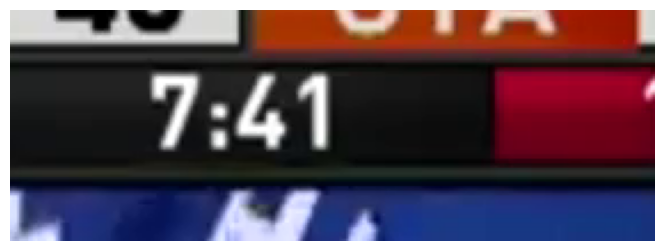

In [12]:
import cv2
import matplotlib.pyplot as plt

video_path = "/kaggle/input/datasets/yerinim/basketball/1_.mp4"

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()
cap.release()

h, w = frame.shape[:2]

# 일단 후보 crop. 안 맞으면 숫자 바꿀 거야.
crop = frame[int(h*0.83):int(h*0.90), int(w*0.73):int(w*0.84)]

plt.figure(figsize=(10, 3))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yerinim/basketball/1_.mp4
